## E-Commerce Sales Analysis Dashboard

**Objective**

Analyze an e-commerce sales dataset and create a dashboard using Matplotlib to answer business questions.

Dataset Columns:

- order_id
- order_date
- customer_id
- product_category
- region
- quantity
- unit_price
- discount
- payment_method
- delivery_days
- customer_rating
- revenue



In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/ecommerce_sales.csv")

df["order_date"] = pd.to_datetime(df["order_date"])
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month_name()
df["month"] = pd.Categorical(
    df["month"],
    categories=[
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ],
)
# pd.categorical helps ensure the months are plotted in the correct chronological order

C:\Users\User\AppData\Local\Temp\ipykernel_33916\3246111503.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby("month")["revenue"].sum()


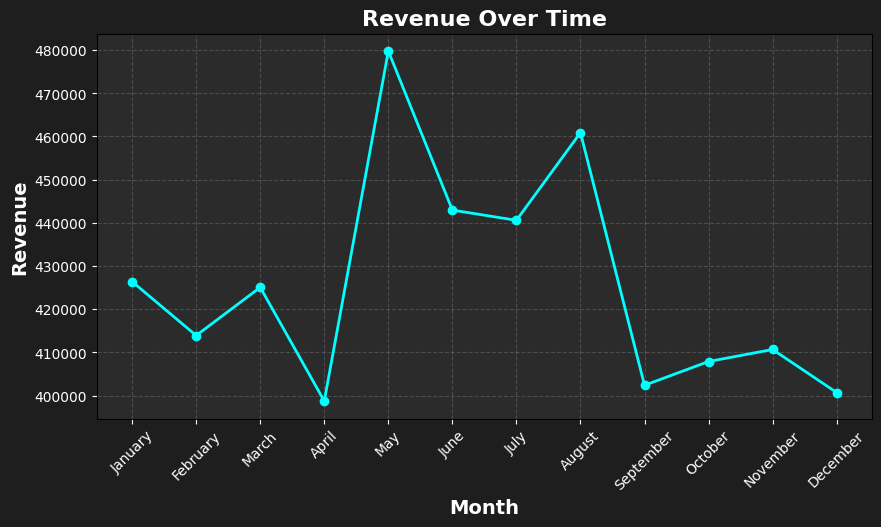

In [6]:
# 1. Line Plot for Revenue Over Months
# Question: How has the revenue changed over the months?

monthly_sales = df.groupby("month")["revenue"].sum()
# monthly_sales.index means names of the months, which will be plotted on the x-axis of the graph.
# monthly_sales.values means respective revenue values for each month, which will be plotted on the y-axis of the graph.

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")


plt.plot(
    monthly_sales.index, monthly_sales.values, marker="o", color="cyan", linewidth=2
)

plt.title("Revenue Over Time", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Month", fontsize=14, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=14, fontweight="bold", color="white")
plt.xticks(rotation=45)
plt.tick_params(axis="both", colors="white")
plt.grid(linestyle="--", alpha=0.25)
plt.savefig("outputs/Revenue_Over_Months.png", dpi=300, bbox_inches="tight")
plt.show()

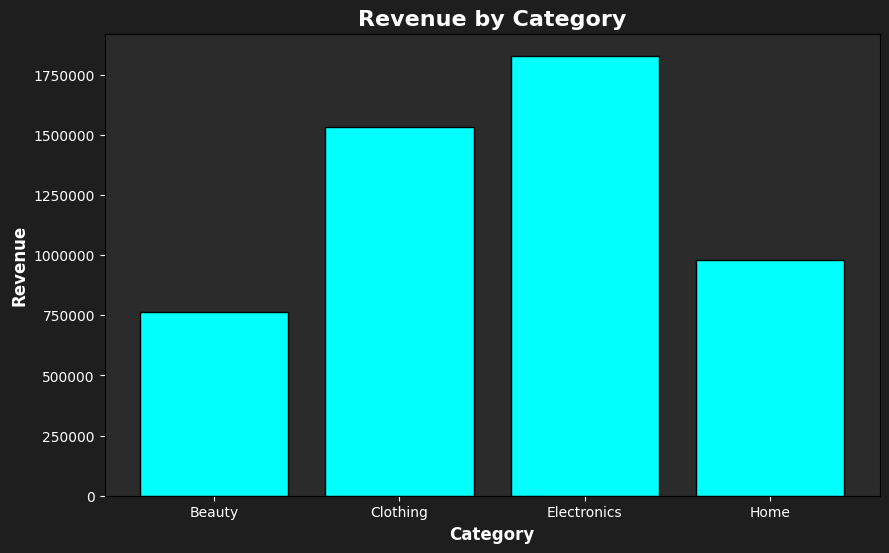

In [7]:
# 2. Bar Plot for Revenue by Product Category
# Question: What is the total revenue generated by each product category?
cat_sales = df.groupby("product_category")["revenue"].sum()

fig = plt.figure(figsize=(10, 6))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.bar(cat_sales.index, cat_sales.values, color="cyan", edgecolor="black")

plt.title("Revenue by Category", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Category", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.ticklabel_format(style="plain", axis="y")  # to remove 1e6 format on y axis
plt.tick_params(axis="both", colors="white")
plt.savefig("outputs/Revenue_by_Product_Category.png", dpi=300, bbox_inches="tight")
plt.show()

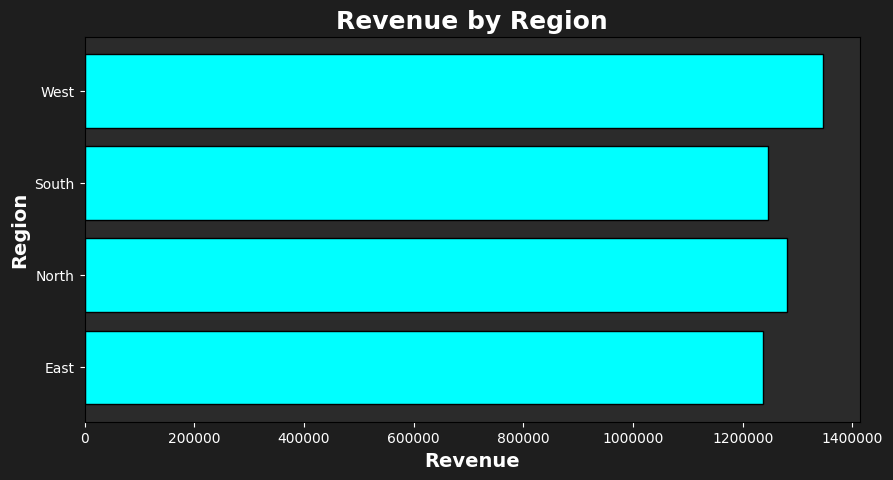

In [8]:
# 3. Horizontal Bar Plot for Revenue by Region
# Question: Which region has generated the highest revenue?

region_sales = df.groupby("region")["revenue"].sum()

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

plt.barh(region_sales.index, region_sales.values, color="cyan", edgecolor="black")

plt.title("Revenue by Region", fontsize=18, fontweight="bold", color="white")
plt.xlabel("Revenue", fontsize=14, fontweight="bold", color="white")
plt.ylabel("Region", fontsize=14, fontweight="bold", color="white")
# plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="x")  # to remove 1e6 format on x axis
plt.tick_params(axis="both", colors="white")
plt.savefig("outputs/Revenue_by_Region.png", dpi=300, bbox_inches="tight")
plt.show()